# Post 01: Initialize an MD Simulation Without Biasing the Result

This notebook is the presentation layer for the first tutorial. The reusable initialization, provenance, and figure logic lives in `src/kups_md_tutorials/`.

The goal is to make the initial state auditable: the cell, structure, velocity draw, center-of-mass removal, seed, config hash, and software versions should all be recoverable from committed files.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.config import load_tutorial_spec
from kups_md_tutorials.figures import generate_post01_figures
from kups_md_tutorials.initialization import initialize_atoms, summarize_initialization
from kups_md_tutorials.provenance import provenance

## Configuration

The smoke profile is intentionally small enough to run on CPU, and the full profile uses the same initialization path with a larger FCC cell. The configuration fixes the argon density, velocity seed, and whether center-of-mass momentum is removed.

In [3]:
smoke_spec = load_tutorial_spec("01", "smoke")
full_spec = load_tutorial_spec("01", "full")
smoke_config_path = Path("configs/post-01/smoke.json")
full_config_path = Path("configs/post-01/full.json")

for label, config_path in [("smoke", smoke_config_path), ("full", full_config_path)]:
    print(f"--- {label} ---")
    print(json.dumps(json.loads(config_path.read_text()), indent=2))

--- smoke ---
{
  "post": "01",
  "profile": "smoke",
  "title": "How Do You Initialize an MD Simulation Without Biasing the Result?",
  "system": {
    "kind": "argon_fcc",
    "repetitions": 2,
    "number_density": 0.0213
  },
  "initialization": {
    "temperature_k": 94.4,
    "seed": 2026071401,
    "remove_center_of_mass": true,
    "force_exact_temperature": false
  }
}
--- full ---
{
  "post": "01",
  "profile": "full",
  "title": "How Do You Initialize an MD Simulation Without Biasing the Result?",
  "system": {
    "kind": "argon_fcc",
    "repetitions": 5,
    "number_density": 0.0213
  },
  "initialization": {
    "temperature_k": 94.4,
    "seed": 2026071401,
    "remove_center_of_mass": true,
    "force_exact_temperature": false
  }
}


## Deterministic initial state

A reproducible initial state is not only a set of coordinates. It also includes the random velocity draw and post-processing choices such as center-of-mass removal. The instantaneous kinetic temperature is allowed to fluctuate because both profiles sample Maxwell-Boltzmann momenta without forcing the exact target temperature.

In [4]:
summaries = {}
for label, spec, config_path in [
    ("smoke", smoke_spec, smoke_config_path),
    ("full", full_spec, full_config_path),
]:
    atoms = initialize_atoms(spec)
    summaries[label] = summarize_initialization(atoms, spec, provenance(config_path).config_sha256)

summaries

{'smoke': InitializationSummary(post='01', profile='smoke', atom_count=32, chemical_formula='Ar32', volume=1502.3474178403744, number_density=0.021300000000000017, target_temperature_k=94.4, instantaneous_temperature_k=103.23132783754575, kinetic_energy_ev=0.42699765750033536, center_of_mass_speed=7.045623056532181e-19, seed=2026071401, config_sha256='0d654a2a2097eac2e54cd3a59f9d2cc77f18641618f3bcdcc0e045deea52a848'),
 'full': InitializationSummary(post='01', profile='full', atom_count=500, chemical_formula='Ar500', volume=23474.178403755832, number_density=0.021300000000000034, target_temperature_k=94.4, instantaneous_temperature_k=90.89870854463463, kinetic_energy_ev=5.8747814906665905, center_of_mass_speed=9.35109305913735e-19, seed=2026071401, config_sha256='97f10e793ad6e7993963660d5886b2b34251f12f53bcba4e5bcb9f629fbc54e3')}

## Committed outputs

The repository commits compact smoke outputs for quick regression checks and full initialization outputs for the diagnostic figure used in the hidden website draft. Larger raw trajectories remain outside version control.

In [5]:
result_dirs = {
    "smoke": Path("results/post-01/smoke"),
    "full": Path("results/post-01/full"),
}
committed_summaries = {}

for label, result_dir in result_dirs.items():
    print(f"--- {label} ---")
    for path in sorted(result_dir.iterdir()):
        print(f"{path}: {path.stat().st_size} bytes")
    committed_summaries[label] = json.loads((result_dir / "initialization_summary.json").read_text())

committed_summaries

--- smoke ---
results/post-01/smoke/initial_state.extxyz: 3509 bytes
results/post-01/smoke/initialization_summary.json: 452 bytes
results/post-01/smoke/manifest.json: 945 bytes
--- full ---
results/post-01/full/initial_state.extxyz: 52650 bytes
results/post-01/full/initialization_summary.json: 450 bytes
results/post-01/full/manifest.json: 943 bytes


{'smoke': {'atom_count': 32,
  'center_of_mass_speed': 7.045623056532181e-19,
  'chemical_formula': 'Ar32',
  'config_sha256': '0d654a2a2097eac2e54cd3a59f9d2cc77f18641618f3bcdcc0e045deea52a848',
  'instantaneous_temperature_k': 103.23132783754575,
  'kinetic_energy_ev': 0.42699765750033536,
  'number_density': 0.021300000000000017,
  'post': '01',
  'profile': 'smoke',
  'seed': 2026071401,
  'target_temperature_k': 94.4,
  'volume': 1502.3474178403744},
 'full': {'atom_count': 500,
  'center_of_mass_speed': 9.35109305913735e-19,
  'chemical_formula': 'Ar500',
  'config_sha256': '97f10e793ad6e7993963660d5886b2b34251f12f53bcba4e5bcb9f629fbc54e3',
  'instantaneous_temperature_k': 90.89870854463463,
  'kinetic_energy_ev': 5.8747814906665905,
  'number_density': 0.021300000000000034,
  'post': '01',
  'profile': 'full',
  'seed': 2026071401,
  'target_temperature_k': 94.4,
  'volume': 23474.178403755832}}

## Diagnostic figure

The full-profile figure is the publication diagnostic because the larger atom count gives a smoother velocity histogram while using the same initialization logic as the smoke profile.

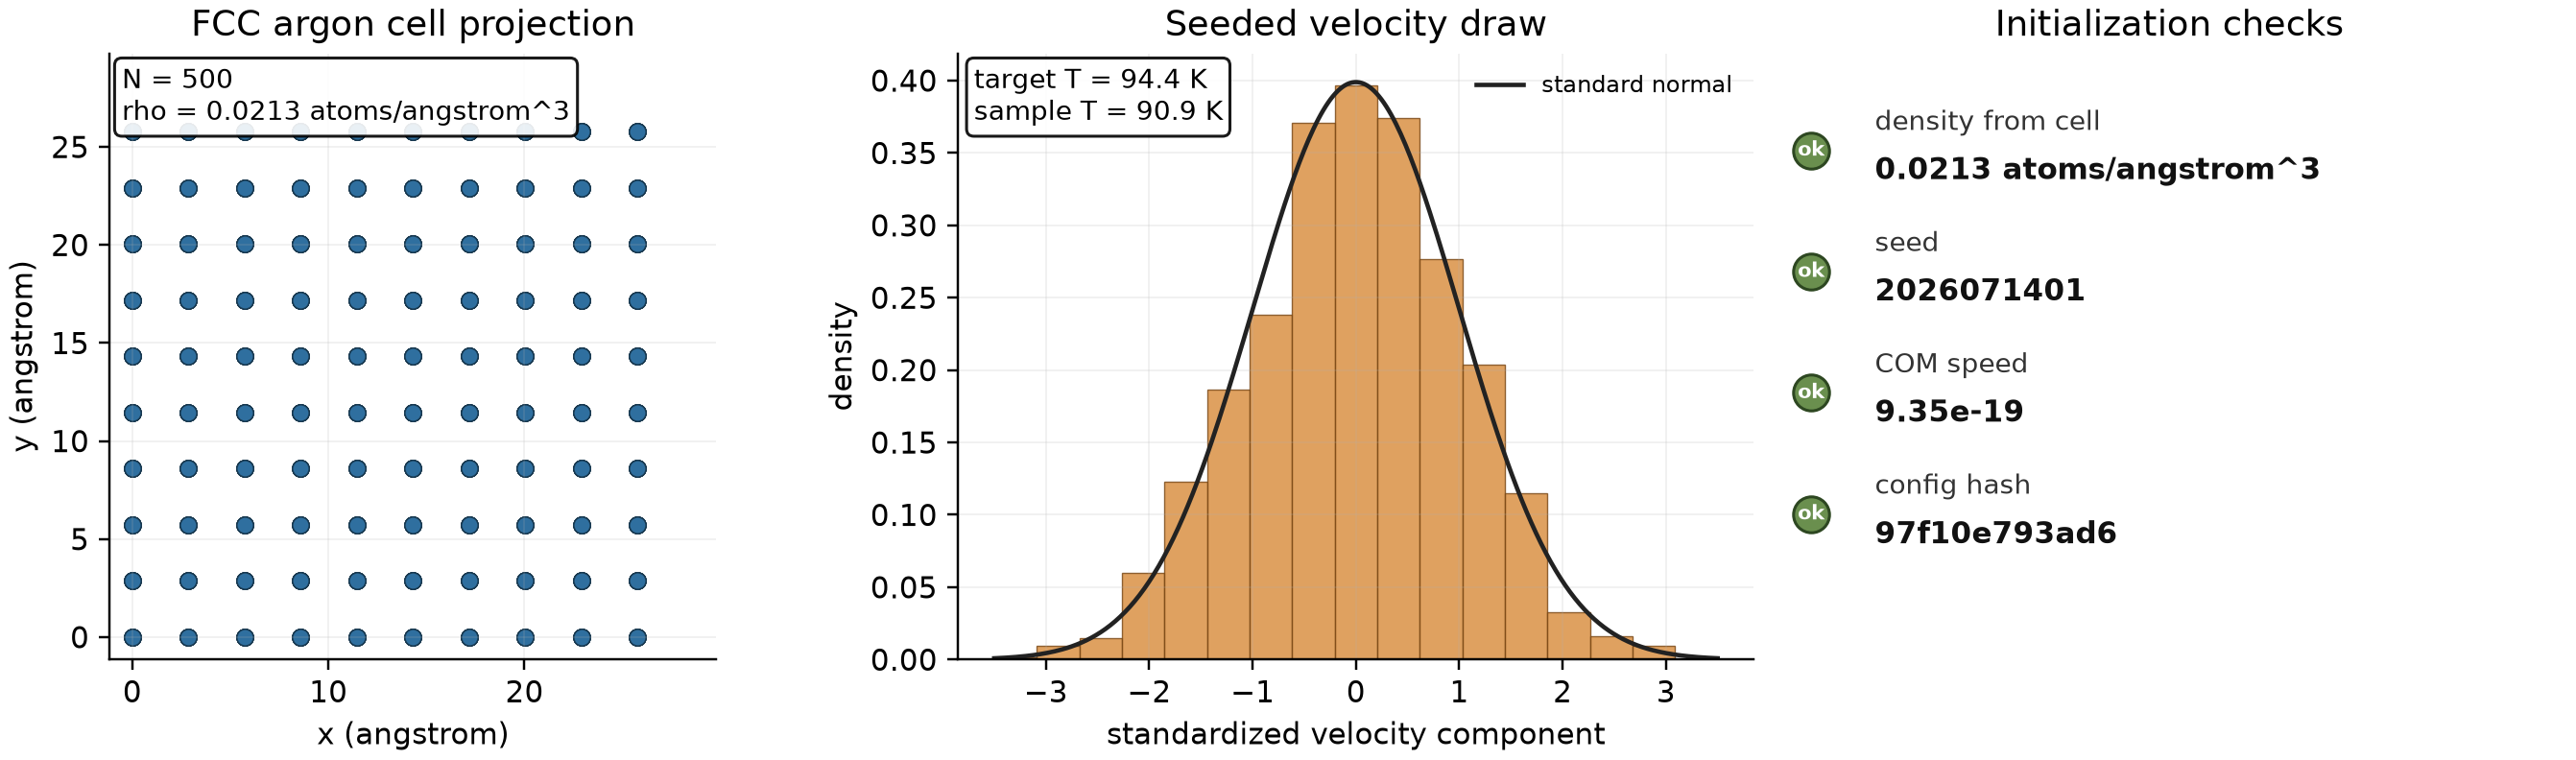

In [6]:
generate_post01_figures(
    result_dir=result_dirs["full"],
    figure_dir=Path("figures/post-01"),
    snapshot_dir=Path("snapshots/post-01"),
    name="initialization_diagnostics_full",
)
display(Image(filename="figures/post-01/initialization_diagnostics_full.png"))

## Takeaways

- The density, cell, seed, and post-processing choices are part of the scientific result.
- Small systems can have kinetic temperatures that differ noticeably from the target when velocities are sampled rather than exactly rescaled.
- The full profile is useful for visual diagnostics, but it is not a substitute for recording the initialization contract.
- Center-of-mass removal should be recorded because it changes the initialized momenta and the effective degrees of freedom.
- The manifest links the generated outputs back to the exact config and Git revision.